# Prática 05 - Propagação de doenças
---
Dupla:
* Diane Fenzi Gonçalves (2019006574)
* Rubia Alice Moreira de Souza (2022043507)

## Imports
---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Constantes
---

In [ ]:
PESSOA_INFECTADA = 0
PESSOA_SAUDAVEL = 1
PESSOA_RECUPERADA = 2

## Criação da Rede SIR
---

In [ ]:
def criarRede(tamanho: int) -> list[list]:
  linhas: int = int(np.sqrt(tamanho))
  colunas: int = int(np.sqrt(tamanho))

  rede = np.ones((linhas, colunas))
  return rede

In [ ]:
def adicionarPessoasInfectadas(
    rede,
    quantidadePessoasInfectadas: int
  ) -> list[list]:

  contadorPessoasInfectadas: int = 0

  while(contadorPessoasInfectadas < quantidadePessoasInfectadas):
    for i in range(len(rede)):
      for j in range(len(rede[i])):
        valorAleatorio = np.random.rand()

        if(valorAleatorio >= 0.5):
          rede[i][j] = PESSOA_INFECTADA
          contadorPessoasInfectadas += 1

        if(contadorPessoasInfectadas == quantidadePessoasInfectadas):
          break

      if(contadorPessoasInfectadas == quantidadePessoasInfectadas):
        break

  return rede

In [ ]:
def criarRedeSIR(tamanho: int, quantidadePessoasInfectadas: int):
  rede = criarRede(tamanho)
  adicionarPessoasInfectadas(rede, quantidadePessoasInfectadas)
  return rede

In [ ]:
def plotRedeSIR(rede, titulo: str = 'Rede SIR') -> None:
  values = np.unique(rede.ravel())

  plt.figure(figsize=(8,4))
  im = plt.imshow(rede)

  cmap = {
    0: [1.0, 0.1, 1.0 ,1],
    1: [1.0, 0.5, 0.1, 1],
    2: [0.1, 1.0, 1.0, 1]
  }
  labels = {0: 'Infectada', 1: 'Saudável', 2: 'Recuperada'}
  arrayShow = np.array([[cmap[i] for i in j] for j in rede])
  patches = [mpatches.Patch(color=cmap[i],label=labels[i]) for i in cmap]

  plt.imshow(arrayShow)
  plt.title(titulo)
  plt.legend(handles=patches, loc=4, borderaxespad=0.)
  plt.show()

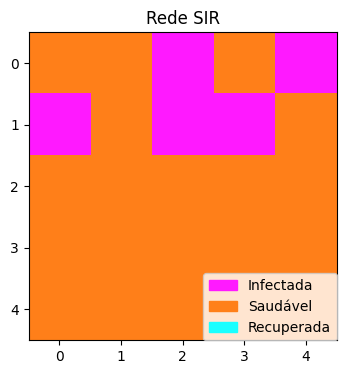

In [ ]:
plotRedeSIR(criarRedeSIR(25, 5))

## Definição da Simulação
---

In [ ]:
def getVizinhoEsquerdo(i: int, j: int, rede):
  if(j == 0):
    return (i, len(rede[i]) - 1)

  return (i, j - 1)

In [ ]:
def getVizinhoDireito(i: int, j: int, rede):
  if(j == len(rede[i]) - 1):
    return (i, 0)

  return (i, j + 1)

In [ ]:
def getVizinhoAcima(i: int, j: int, rede):
  if(i == 0):
    return (len(rede) - 1, j)

  return (i - 1, j)

In [ ]:
def getVizinhoAbaixo(i: int, j: int, rede):
  if(i == len(rede) - 1):
    return (0, j)

  return (i + 1, j)

In [ ]:
def tentarInfectarVizinho(
    rede,
    i: int,
    j: int,
    probabilidadeInfeccao: float,
    devePrintar: bool = False
  ):

  pessoa = rede[i][j]
  if(pessoa != PESSOA_SAUDAVEL):
    return

  valorInfeccao = np.random.rand()
  if(valorInfeccao > (1 - probabilidadeInfeccao)):
    if(devePrintar):
      print(f"Infectado: ({i}, {j})")
    rede[i][j] = PESSOA_INFECTADA

In [ ]:
def tentarInfectarVizinhos(
    rede,
    i: int,
    j: int,
    probabilidadeInfeccao: float,
    devePrintar: bool = False,
  ):

  indiceVizinhoEsquerdo = getVizinhoEsquerdo(i, j, rede)
  tentarInfectarVizinho(
    rede,
    indiceVizinhoEsquerdo[0],
    indiceVizinhoEsquerdo[1],
    probabilidadeInfeccao,
    devePrintar
  )

  indiceVizinhoDireito = getVizinhoDireito(i, j, rede)
  tentarInfectarVizinho(
    rede,
    indiceVizinhoDireito[0],
    indiceVizinhoDireito[1],
    probabilidadeInfeccao,
    devePrintar
  )

  indiceVizinhoAcima = getVizinhoAcima(i, j, rede)
  tentarInfectarVizinho(
    rede,
    indiceVizinhoAcima[0],
    indiceVizinhoAcima[1],
    probabilidadeInfeccao,
    devePrintar
  )

  indiceVizinhoAbaixo = getVizinhoAbaixo(i, j, rede)
  tentarInfectarVizinho(
    rede,
    indiceVizinhoAbaixo[0],
    indiceVizinhoAbaixo[1],
    probabilidadeInfeccao,
    devePrintar
  )

In [ ]:
def simularPassoSIR(
    rede,
    probabilidadeInfeccao: float,
    probabilidadeRecuperacao: float,
    devePrintar: bool = False,
  ):

  for i in range(len(rede)):
    for j in range(len(rede[i])):
      pessoa = rede[i][j]

      if(pessoa != PESSOA_INFECTADA):
        continue

      valorRecuperacao = np.random.rand()
      if(valorRecuperacao > (1 - probabilidadeRecuperacao)):
        if(devePrintar):
          print(f"Recuperado: ({i}, {j})")

        rede[i][j] = PESSOA_RECUPERADA
        continue

      tentarInfectarVizinhos(rede, i, j, probabilidadeInfeccao, devePrintar)

In [ ]:
def simularSIR(
    rede,
    quantidadeIteracoes: int,
    probabilidadeInfeccao: float,
    probabilidadeRecuperacao: float,
    devePrintar: bool = False,
    devePlotar: bool = False
  ):

  if(devePlotar):
    plotRedeSIR(rede, "Estado Inicial")

  for iteracao in range(quantidadeIteracoes):
    if(devePrintar):
      print(f"==== Iteração: {iteracao} ====")

    simularPassoSIR(
      rede,
      probabilidadeInfeccao,
      probabilidadeRecuperacao,
      devePrintar
    )

    if(devePlotar):
      plotRedeSIR(rede, f"Iteração: {iteracao}")

  return rede

## Visualização da Distribuição Espacial
---

### Infecção e recuperação baixas
---

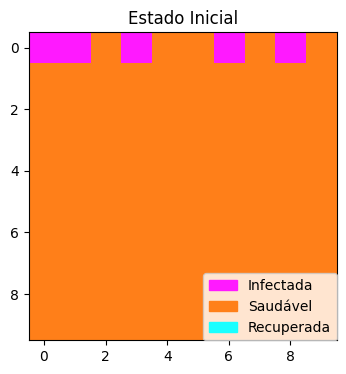

==== Iteração: 0 ====
Infectado: (1, 0)
Infectado: (1, 1)
Infectado: (9, 3)
Infectado: (1, 3)
Infectado: (0, 5)
Infectado: (1, 9)
Recuperado: (1, 1)
Infectado: (1, 8)
Infectado: (0, 9)
Infectado: (9, 4)
Infectado: (8, 3)


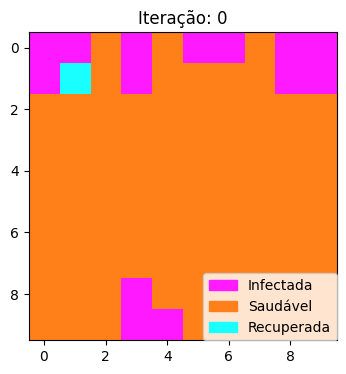

==== Iteração: 1 ====
Recuperado: (0, 1)
Infectado: (0, 4)
Infectado: (9, 5)
Recuperado: (1, 3)
Infectado: (1, 7)
Infectado: (2, 8)
Infectado: (2, 9)
Infectado: (3, 9)
Recuperado: (3, 9)
Infectado: (8, 2)
Recuperado: (9, 3)


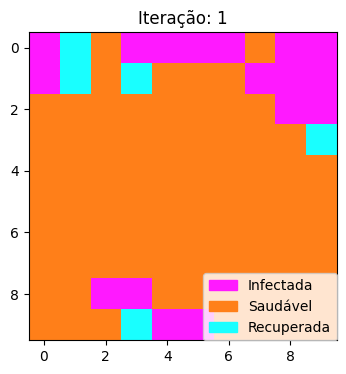

==== Iteração: 2 ====
Infectado: (0, 2)
Recuperado: (0, 4)
Infectado: (9, 8)
Infectado: (2, 7)
Infectado: (3, 8)
Recuperado: (2, 9)
Infectado: (7, 2)
Recuperado: (8, 3)


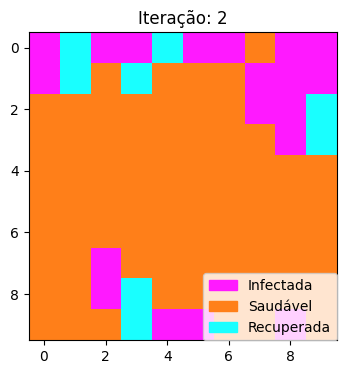

==== Iteração: 3 ====
Infectado: (9, 0)
Infectado: (9, 2)
Recuperado: (0, 5)
Recuperado: (0, 6)
Infectado: (0, 7)
Recuperado: (0, 9)
Infectado: (2, 0)
Recuperado: (7, 2)
Recuperado: (8, 2)
Infectado: (9, 9)
Infectado: (9, 1)
Recuperado: (9, 2)


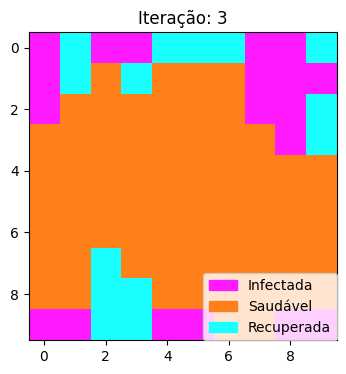

==== Iteração: 4 ====
Infectado: (1, 2)
Recuperado: (1, 0)
Recuperado: (2, 7)
Recuperado: (2, 8)
Recuperado: (3, 8)
Infectado: (8, 5)
Recuperado: (9, 9)


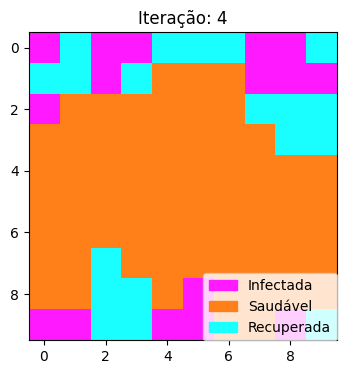

==== Iteração: 5 ====
Recuperado: (0, 3)
Infectado: (9, 7)
Recuperado: (1, 9)
Recuperado: (9, 1)
Infectado: (8, 7)
Recuperado: (9, 8)


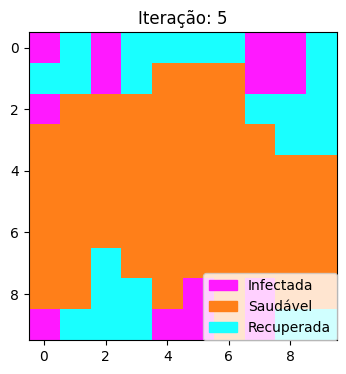

==== Iteração: 6 ====
Recuperado: (0, 8)
Infectado: (2, 2)
Infectado: (2, 1)
Infectado: (3, 1)
Infectado: (8, 4)


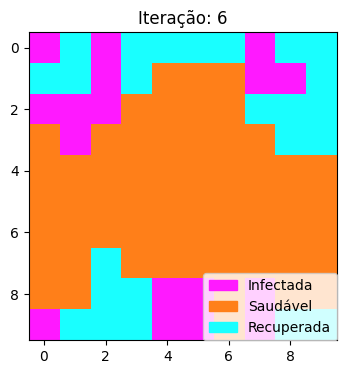

==== Iteração: 7 ====
Infectado: (1, 6)
Infectado: (3, 0)
Infectado: (3, 2)
Infectado: (8, 6)
Infectado: (7, 5)
Infectado: (8, 0)


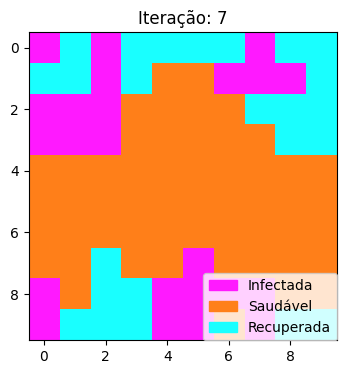

==== Iteração: 8 ====
Recuperado: (1, 6)
Recuperado: (1, 8)
Infectado: (4, 1)
Infectado: (5, 1)
Infectado: (5, 2)
Infectado: (6, 1)
Infectado: (5, 3)
Infectado: (6, 0)
Recuperado: (8, 4)
Recuperado: (8, 7)


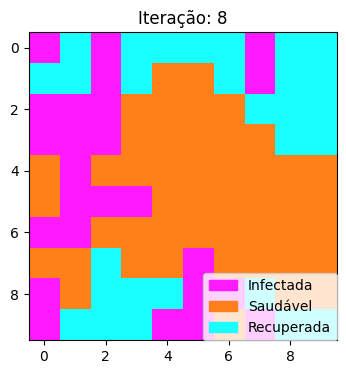

==== Iteração: 9 ====
Infectado: (5, 0)
Infectado: (9, 6)
Recuperado: (9, 0)


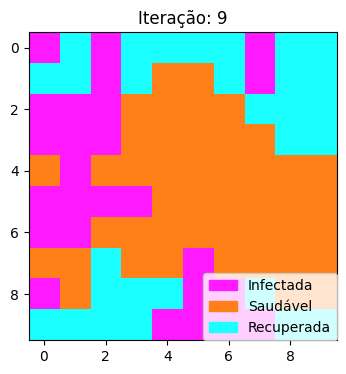

==== Iteração: 10 ====
Recuperado: (0, 0)
Recuperado: (0, 7)
Recuperado: (1, 2)
Infectado: (3, 3)
Infectado: (4, 2)
Infectado: (2, 3)
Infectado: (7, 6)


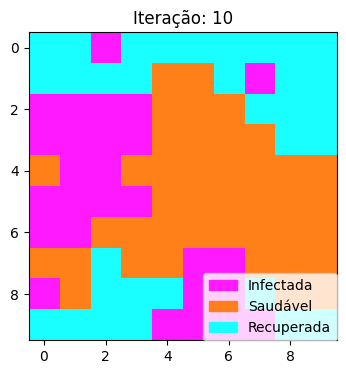

==== Iteração: 11 ====
Recuperado: (1, 7)
Infectado: (2, 4)
Infectado: (4, 0)
Recuperado: (3, 3)
Recuperado: (4, 0)
Infectado: (7, 1)
Infectado: (6, 6)
Infectado: (8, 1)


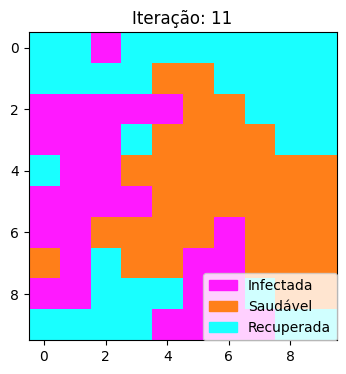

==== Iteração: 12 ====
Infectado: (1, 4)
Infectado: (3, 4)
Infectado: (3, 5)
Infectado: (4, 4)
Recuperado: (4, 2)
Infectado: (4, 3)
Infectado: (4, 5)
Infectado: (4, 6)
Infectado: (5, 5)
Infectado: (5, 9)
Infectado: (6, 3)
Infectado: (6, 5)
Infectado: (4, 9)
Infectado: (7, 0)
Infectado: (6, 4)


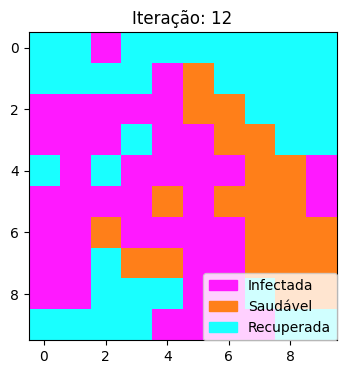

==== Iteração: 13 ====
Infectado: (2, 5)
Infectado: (5, 4)
Recuperado: (5, 2)
Recuperado: (5, 3)
Recuperado: (7, 1)
Recuperado: (9, 4)


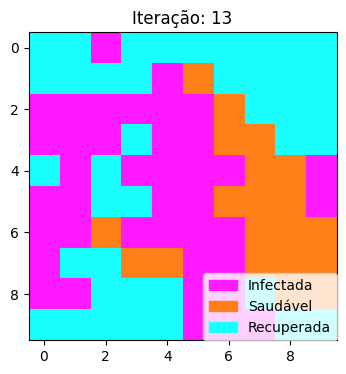

==== Iteração: 14 ====
Recuperado: (0, 2)
Infectado: (1, 5)
Recuperado: (2, 0)
Recuperado: (2, 4)
Recuperado: (4, 3)
Recuperado: (4, 6)
Recuperado: (5, 1)
Infectado: (6, 9)
Recuperado: (6, 3)
Infectado: (5, 6)
Recuperado: (7, 0)
Recuperado: (9, 5)


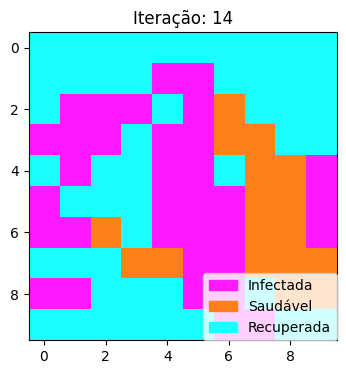

==== Iteração: 15 ====
Recuperado: (1, 4)
Infectado: (3, 6)
Recuperado: (4, 4)
Recuperado: (4, 9)
Recuperado: (5, 6)
Recuperado: (6, 1)
Infectado: (6, 7)
Recuperado: (6, 9)
Infectado: (7, 7)


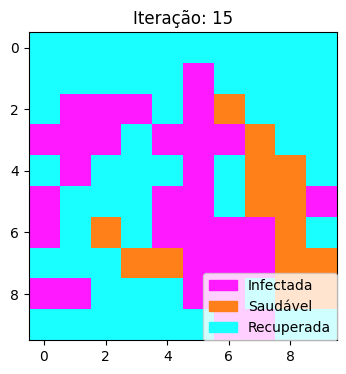

==== Iteração: 16 ====
Recuperado: (2, 2)
Infectado: (2, 6)
Recuperado: (3, 2)
Recuperado: (5, 4)
Recuperado: (7, 5)
Recuperado: (8, 0)


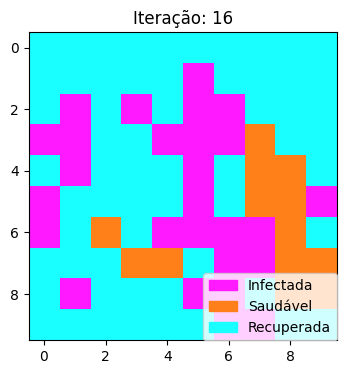

==== Iteração: 17 ====
Recuperado: (5, 0)
Infectado: (5, 8)
Recuperado: (6, 4)
Recuperado: (6, 5)
Recuperado: (6, 6)
Infectado: (6, 8)
Infectado: (7, 8)
Infectado: (8, 8)


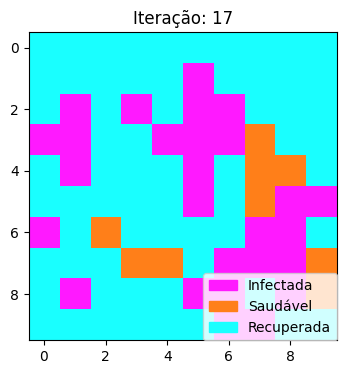

==== Iteração: 18 ====
Recuperado: (2, 5)
Recuperado: (4, 5)
Infectado: (7, 9)
Recuperado: (8, 8)


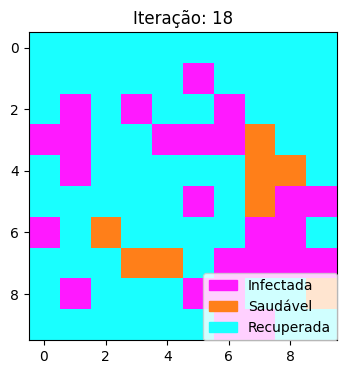

==== Iteração: 19 ====
Recuperado: (5, 5)
Recuperado: (5, 8)
Infectado: (5, 7)
Recuperado: (7, 8)


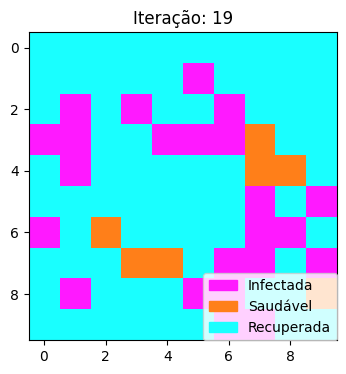

In [ ]:
rede = criarRedeSIR(
  tamanho = 100,
  quantidadePessoasInfectadas = 5
)

rede = simularSIR(
    rede = rede,
    quantidadeIteracoes = 20,
    probabilidadeInfeccao = 0.2,
    probabilidadeRecuperacao = 0.1,
    devePrintar = True,
    devePlotar = True
)

* Quando temos ambos os valores baixos, é possível notar um processo mais lento de propagação da doença, que pode ou não, a depender da simulação, conseguir infectar todos os indivíduos.
* Além disso, ao final da simulação, nem todos os indivíduos infectados conseguiram se recuperar.

### Infecção alta e recuperação baixa
---

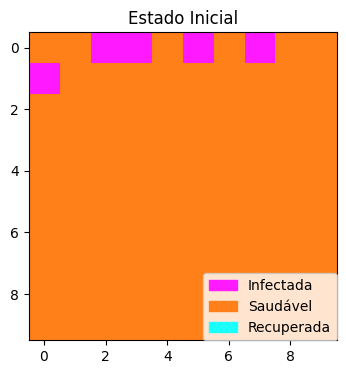

==== Iteração: 0 ====
Infectado: (0, 1)
Infectado: (9, 2)
Infectado: (1, 2)
Infectado: (1, 3)
Infectado: (0, 4)
Infectado: (0, 6)
Infectado: (9, 5)
Infectado: (9, 6)
Infectado: (1, 6)
Infectado: (9, 7)
Infectado: (1, 7)
Infectado: (1, 9)
Infectado: (1, 1)
Infectado: (2, 2)
Recuperado: (1, 3)
Recuperado: (1, 6)
Infectado: (1, 8)
Infectado: (2, 7)
Infectado: (0, 8)
Infectado: (2, 8)
Infectado: (0, 9)
Infectado: (2, 9)
Infectado: (2, 1)
Infectado: (2, 3)
Infectado: (3, 2)
Infectado: (3, 3)
Infectado: (3, 7)
Infectado: (3, 8)
Infectado: (3, 9)
Infectado: (3, 1)
Infectado: (4, 2)
Infectado: (3, 4)
Infectado: (4, 3)
Infectado: (3, 5)
Infectado: (2, 4)
Infectado: (4, 4)
Infectado: (3, 6)
Infectado: (4, 5)
Infectado: (2, 6)
Infectado: (4, 6)
Infectado: (4, 7)
Infectado: (4, 8)
Infectado: (3, 0)
Infectado: (4, 9)
Infectado: (5, 2)
Infectado: (5, 3)
Infectado: (5, 4)
Infectado: (5, 6)
Infectado: (5, 7)
Infectado: (5, 8)
Infectado: (4, 0)
Infectado: (5, 9)
Infectado: (5, 1)
Infectado: (6, 2)
Infe

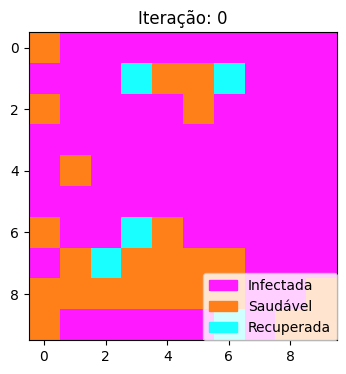

==== Iteração: 1 ====
Infectado: (0, 0)
Recuperado: (0, 3)
Infectado: (1, 4)
Infectado: (1, 5)
Infectado: (9, 8)
Infectado: (2, 0)
Recuperado: (1, 1)
Recuperado: (1, 2)
Recuperado: (2, 0)
Recuperado: (2, 2)
Recuperado: (2, 3)
Infectado: (2, 5)
Recuperado: (2, 8)
Infectado: (4, 1)
Recuperado: (4, 2)
Recuperado: (5, 0)
Recuperado: (5, 4)
Infectado: (6, 0)
Infectado: (7, 1)
Infectado: (6, 4)
Infectado: (7, 5)
Infectado: (7, 6)
Recuperado: (6, 7)
Infectado: (8, 0)
Infectado: (7, 4)
Infectado: (8, 6)
Infectado: (8, 9)
Infectado: (8, 1)
Infectado: (9, 0)
Infectado: (8, 5)
Infectado: (9, 9)
Infectado: (8, 2)
Infectado: (8, 4)


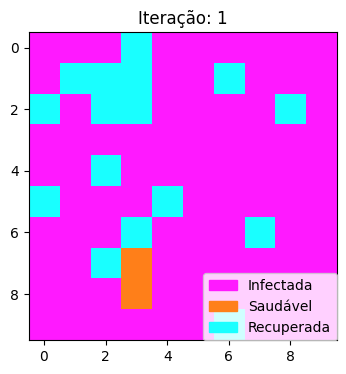

==== Iteração: 2 ====
Recuperado: (0, 2)
Recuperado: (3, 8)
Recuperado: (4, 7)
Recuperado: (4, 9)
Recuperado: (5, 2)
Recuperado: (5, 6)
Recuperado: (6, 9)
Infectado: (7, 3)
Infectado: (8, 3)


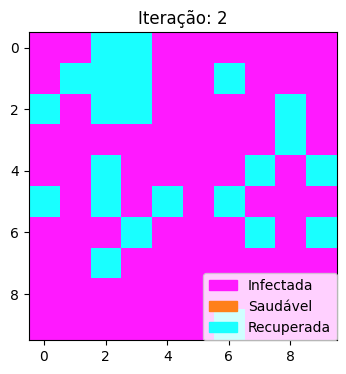

==== Iteração: 3 ====
Recuperado: (0, 1)
Recuperado: (3, 6)
Recuperado: (4, 3)
Recuperado: (6, 4)
Recuperado: (7, 4)
Recuperado: (8, 7)


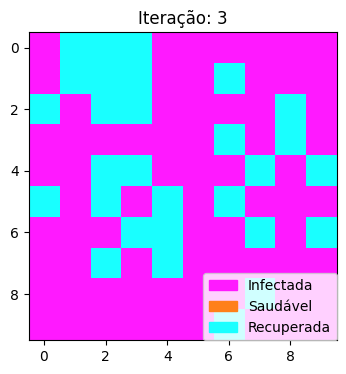

==== Iteração: 4 ====
Recuperado: (3, 4)
Recuperado: (4, 4)
Recuperado: (8, 1)
Recuperado: (9, 5)
Recuperado: (9, 9)


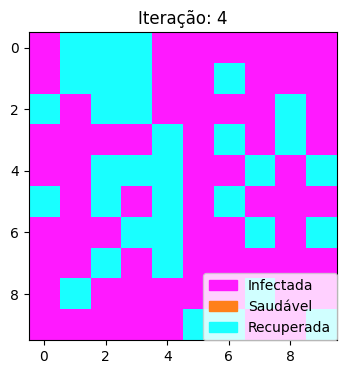

==== Iteração: 5 ====
Recuperado: (0, 5)
Recuperado: (0, 7)
Recuperado: (2, 5)
Recuperado: (3, 7)
Recuperado: (6, 2)
Recuperado: (8, 5)


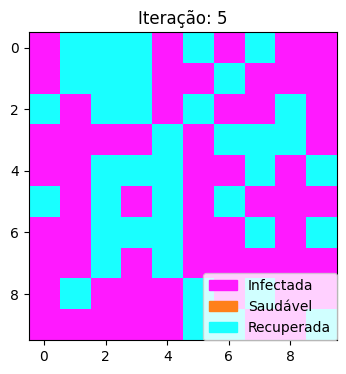

==== Iteração: 6 ====
Recuperado: (1, 5)
Recuperado: (6, 5)
Recuperado: (6, 6)
Recuperado: (8, 6)
Recuperado: (9, 0)


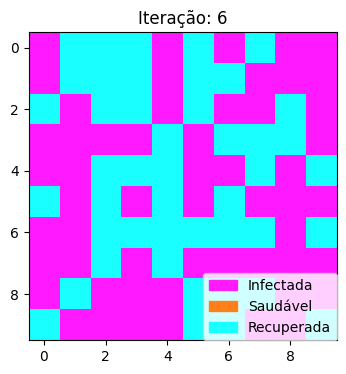

==== Iteração: 7 ====
Recuperado: (1, 9)
Recuperado: (3, 1)
Recuperado: (5, 5)
Recuperado: (9, 2)


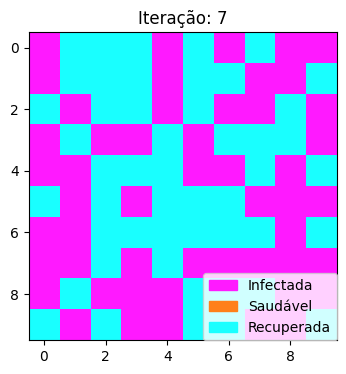

==== Iteração: 8 ====
Recuperado: (1, 0)


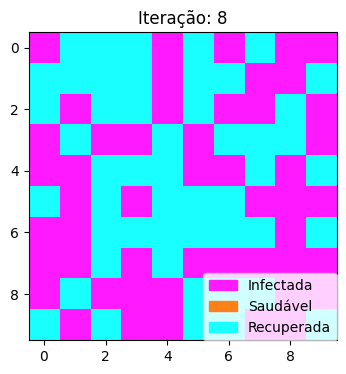

==== Iteração: 9 ====
Recuperado: (3, 9)
Recuperado: (4, 8)
Recuperado: (7, 8)
Recuperado: (8, 0)
Recuperado: (8, 8)
Recuperado: (9, 1)


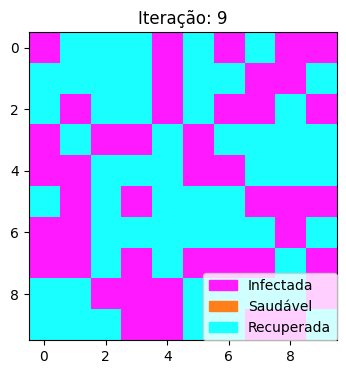

==== Iteração: 10 ====
Recuperado: (0, 4)
Recuperado: (3, 5)
Recuperado: (5, 3)
Recuperado: (6, 0)
Recuperado: (6, 8)
Recuperado: (7, 9)
Recuperado: (9, 3)


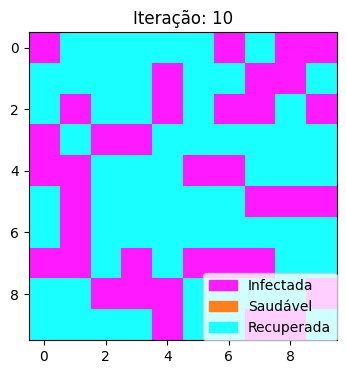

==== Iteração: 11 ====
Recuperado: (3, 0)
Recuperado: (9, 4)


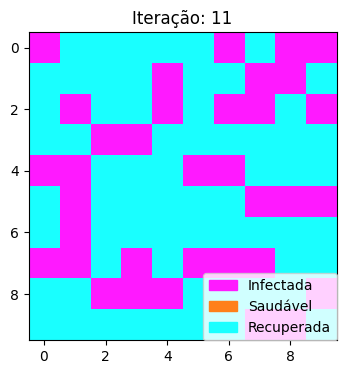

==== Iteração: 12 ====
Recuperado: (0, 8)
Recuperado: (0, 9)
Recuperado: (2, 6)
Recuperado: (2, 7)
Recuperado: (3, 2)
Recuperado: (4, 0)
Recuperado: (7, 3)


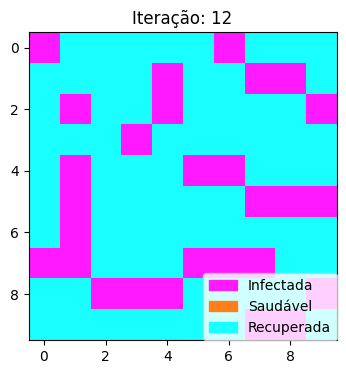

==== Iteração: 13 ====
Recuperado: (2, 4)
Recuperado: (5, 7)


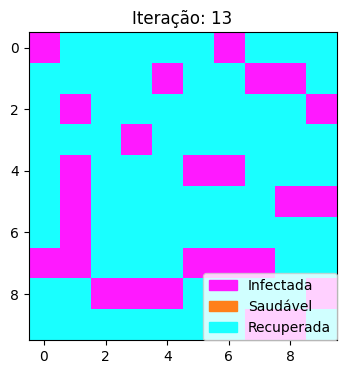

==== Iteração: 14 ====
Recuperado: (5, 8)


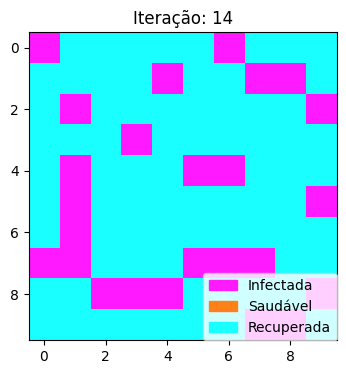

==== Iteração: 15 ====
Recuperado: (1, 8)
Recuperado: (7, 5)


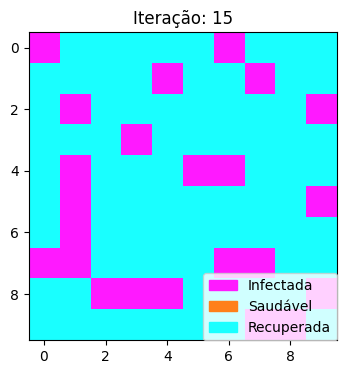

==== Iteração: 16 ====
Recuperado: (0, 6)
Recuperado: (8, 2)
Recuperado: (8, 4)


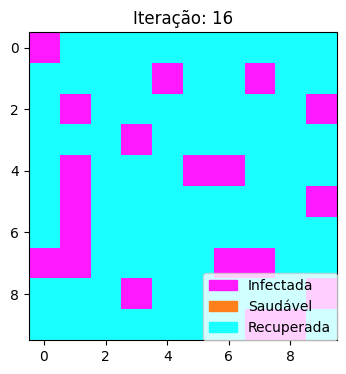

==== Iteração: 17 ====
Recuperado: (4, 1)
Recuperado: (7, 0)
Recuperado: (7, 1)


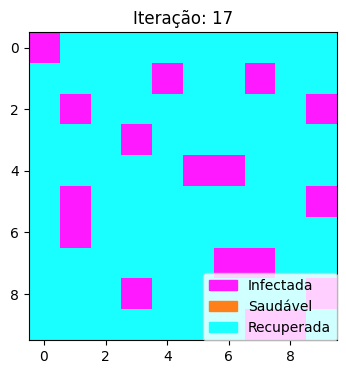

==== Iteração: 18 ====
Recuperado: (7, 7)


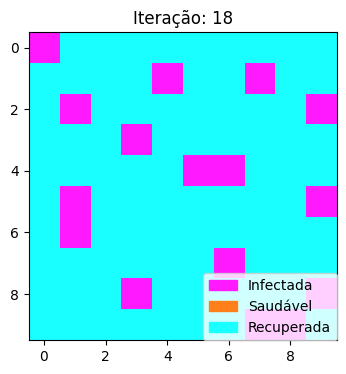

==== Iteração: 19 ====
Recuperado: (3, 3)
Recuperado: (5, 9)


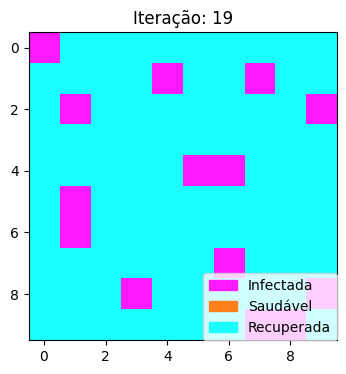

In [ ]:
rede = criarRedeSIR(
  tamanho = 100,
  quantidadePessoasInfectadas = 5
)

rede = simularSIR(
    rede = rede,
    quantidadeIteracoes = 20,
    probabilidadeInfeccao = 0.8,
    probabilidadeRecuperacao = 0.1,
    devePrintar = True,
    devePlotar = True
)

* Com uma taxa de propagação da doença alta e recuperação baixa, é possível notar que ela se expande rapidamente, conseguindo atingir todos os indivíduos beem cedo na simulação.

* Como a taxa de recuperação é baixa, ao final da simulação nem todos os indivíduos infectados conseguiram se recuperar. No entanto, foi apenas uma minoria deles, provavelmente devido ao fato de grande parte deles serem infectados em interações mais iniciais.

### Infecção e recuperação iguais
---

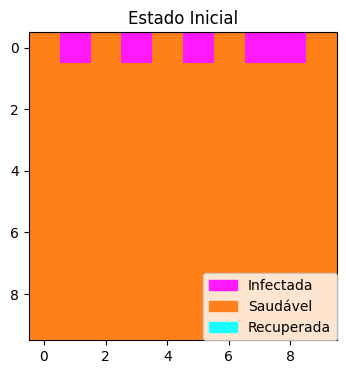

==== Iteração: 0 ====
Infectado: (0, 0)
Infectado: (0, 2)
Recuperado: (0, 2)
Recuperado: (0, 5)
Infectado: (1, 7)
Infectado: (0, 9)
Infectado: (1, 8)
Infectado: (1, 9)
Recuperado: (1, 7)
Recuperado: (1, 8)
Recuperado: (1, 9)


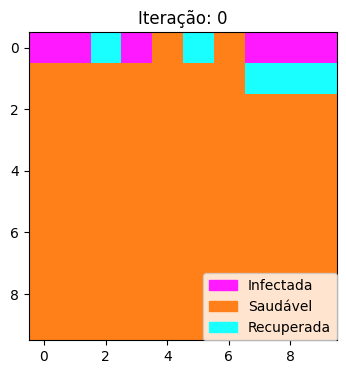

==== Iteração: 1 ====
Infectado: (1, 0)
Recuperado: (0, 1)
Recuperado: (0, 3)
Recuperado: (0, 7)
Recuperado: (1, 0)


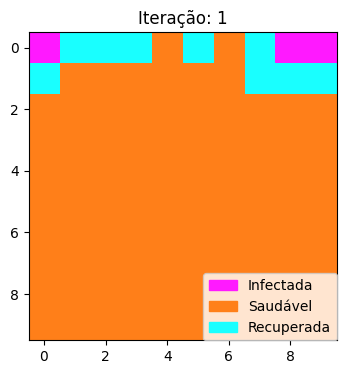

==== Iteração: 2 ====
Infectado: (9, 0)
Infectado: (9, 8)
Recuperado: (0, 9)
Recuperado: (9, 0)
Infectado: (9, 7)
Infectado: (9, 9)
Recuperado: (9, 9)


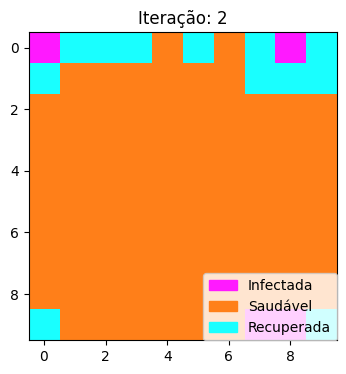

==== Iteração: 3 ====
Recuperado: (9, 7)
Infectado: (8, 8)


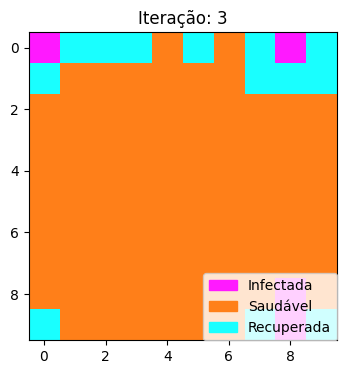

==== Iteração: 4 ====
Recuperado: (0, 0)
Recuperado: (0, 8)
Recuperado: (8, 8)


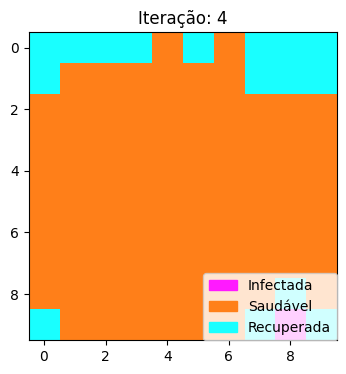

==== Iteração: 5 ====
Recuperado: (9, 8)


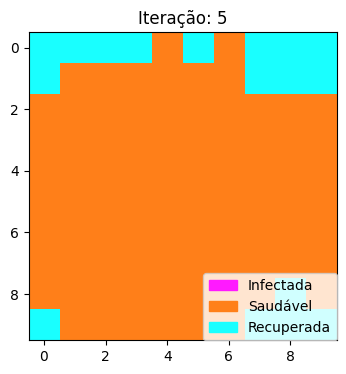

==== Iteração: 6 ====


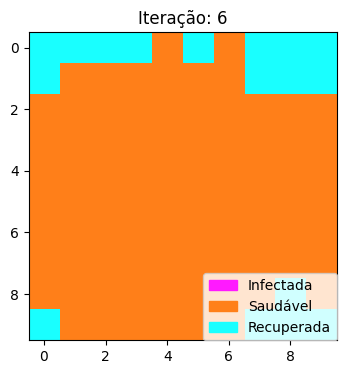

==== Iteração: 7 ====


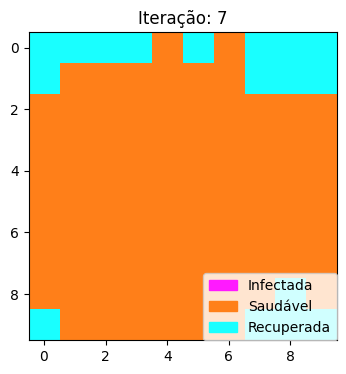

==== Iteração: 8 ====


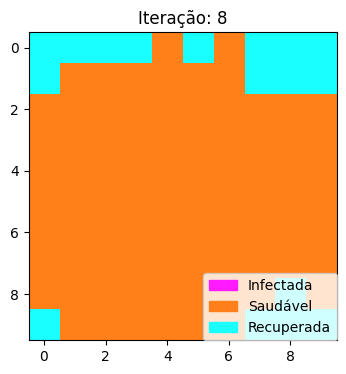

==== Iteração: 9 ====


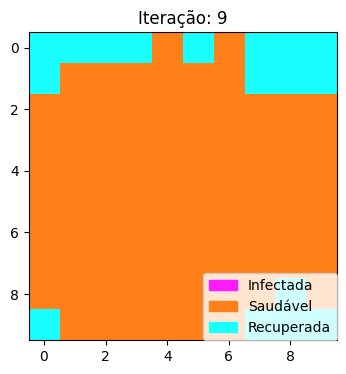

==== Iteração: 10 ====


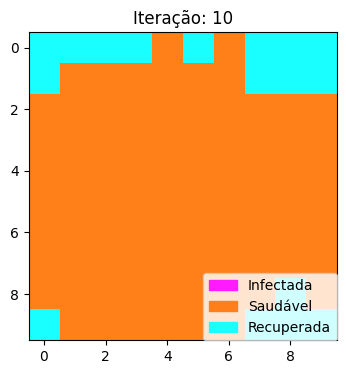

==== Iteração: 11 ====


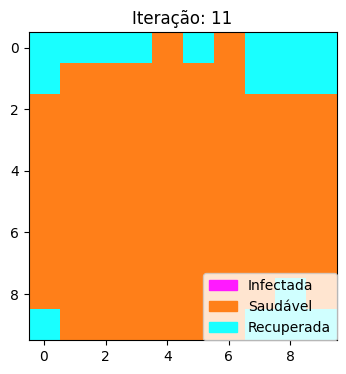

==== Iteração: 12 ====


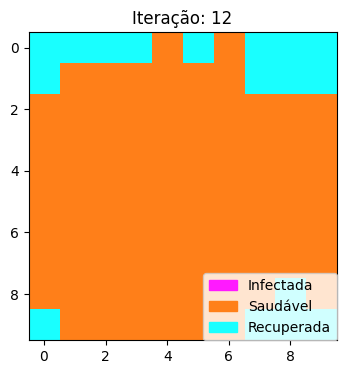

==== Iteração: 13 ====


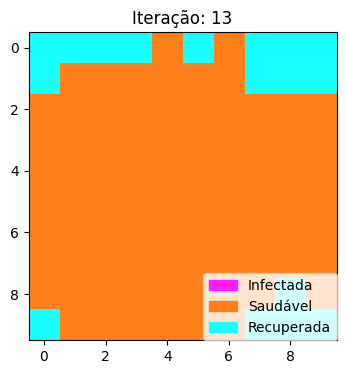

==== Iteração: 14 ====


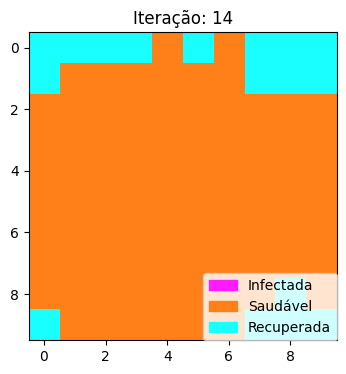

==== Iteração: 15 ====


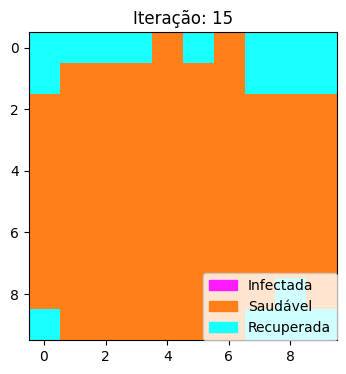

==== Iteração: 16 ====


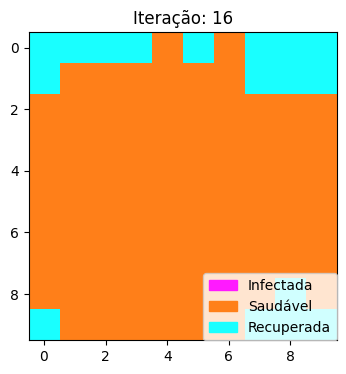

==== Iteração: 17 ====


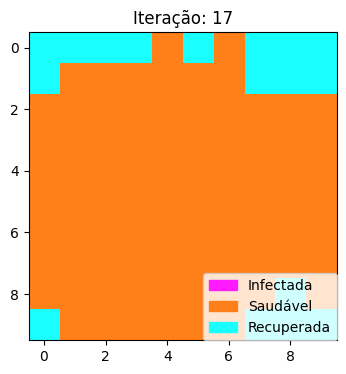

==== Iteração: 18 ====


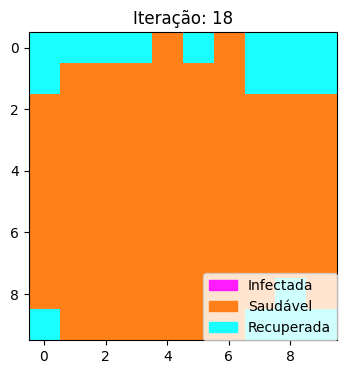

==== Iteração: 19 ====


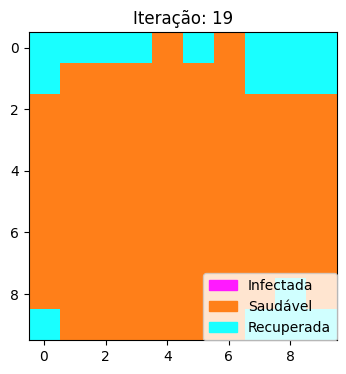

In [ ]:
rede = criarRedeSIR(
  tamanho = 100,
  quantidadePessoasInfectadas = 5
)

rede = simularSIR(
    rede = rede,
    quantidadeIteracoes = 20,
    probabilidadeInfeccao = 0.5,
    probabilidadeRecuperacao = 0.5,
    devePrintar = True,
    devePlotar = True
)

* Neste caso, a doença conseguiu se propagar, mas não chegou a atingir grande parte dos individuos. Assim, muitos deles nem chegaram a ser infectados.

* Aqueles que se mantiveram saudáveis foram os que estavam mais distantes fisicamente dos indivíduos infectados. Isso permitiu que a doença acabasse sendo erradicada antes de atingi-los.

### Infecção baixa e recuperação alta
---

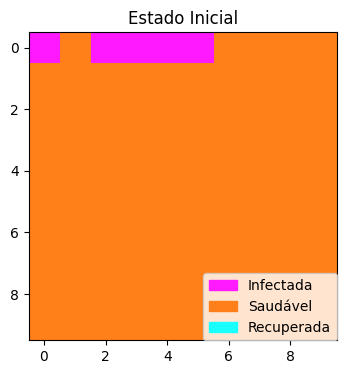

==== Iteração: 0 ====
Infectado: (0, 9)
Infectado: (1, 0)
Recuperado: (0, 2)
Recuperado: (0, 4)
Recuperado: (0, 5)
Infectado: (9, 9)
Infectado: (1, 9)
Recuperado: (9, 9)


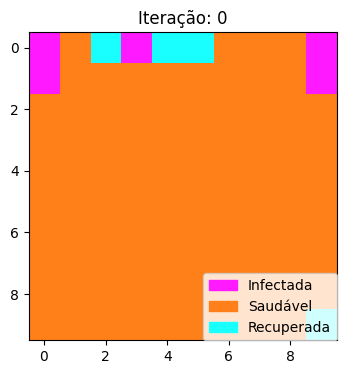

==== Iteração: 1 ====
Recuperado: (0, 0)
Recuperado: (0, 3)
Infectado: (0, 8)
Recuperado: (1, 0)
Infectado: (1, 8)
Infectado: (2, 9)
Recuperado: (2, 9)


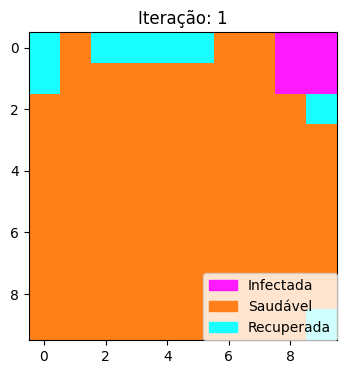

==== Iteração: 2 ====
Recuperado: (0, 8)
Recuperado: (0, 9)
Recuperado: (1, 8)
Recuperado: (1, 9)


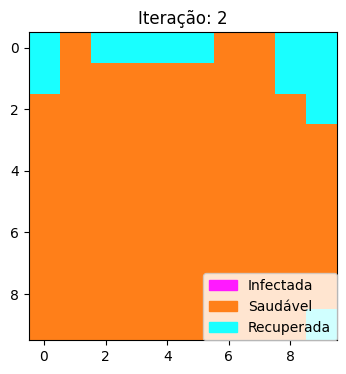

==== Iteração: 3 ====


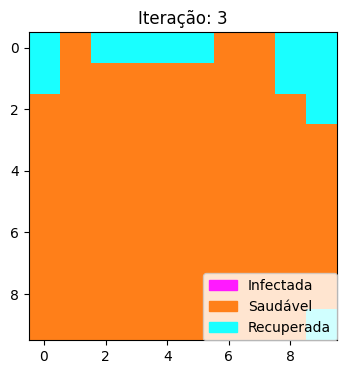

==== Iteração: 4 ====


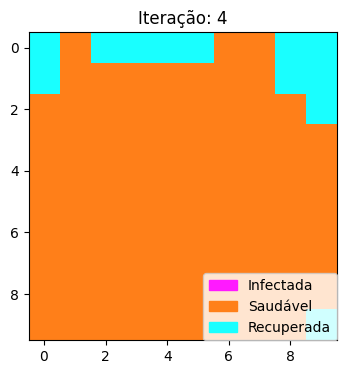

==== Iteração: 5 ====


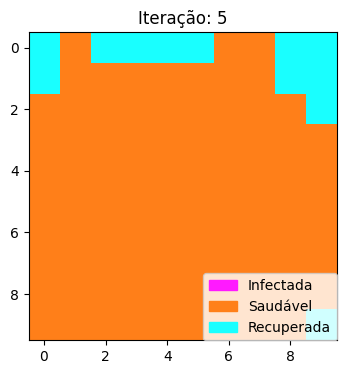

==== Iteração: 6 ====


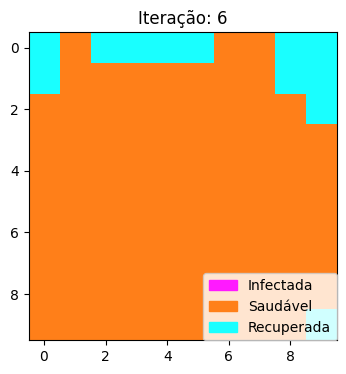

==== Iteração: 7 ====


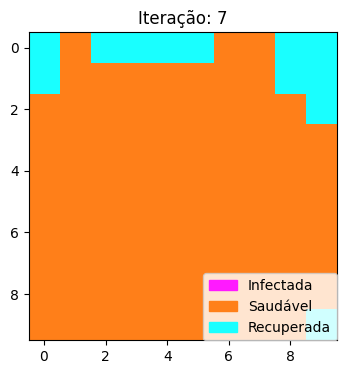

==== Iteração: 8 ====


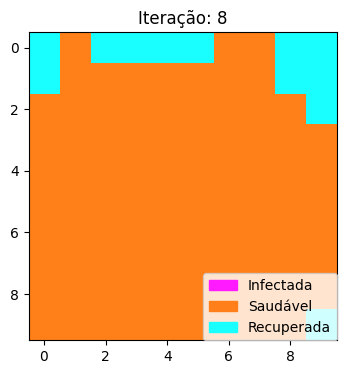

==== Iteração: 9 ====


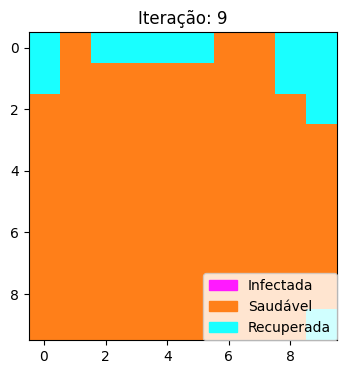

==== Iteração: 10 ====


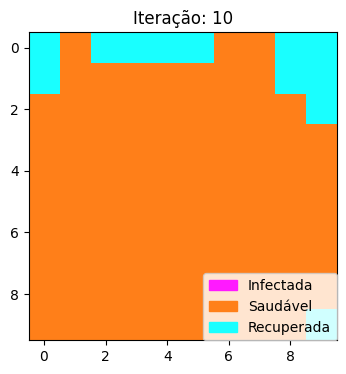

==== Iteração: 11 ====


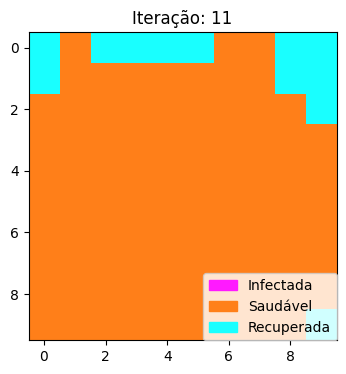

==== Iteração: 12 ====


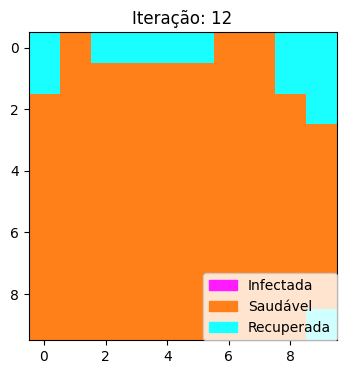

==== Iteração: 13 ====


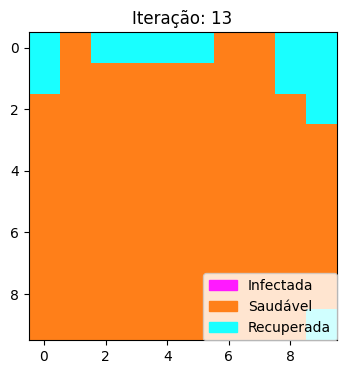

==== Iteração: 14 ====


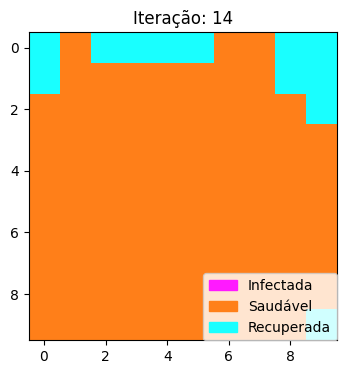

==== Iteração: 15 ====


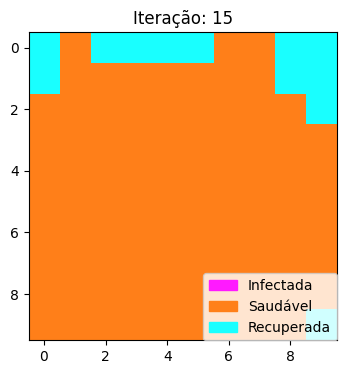

==== Iteração: 16 ====


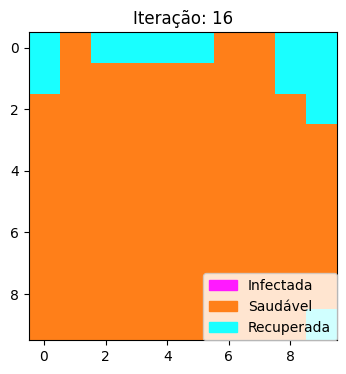

==== Iteração: 17 ====


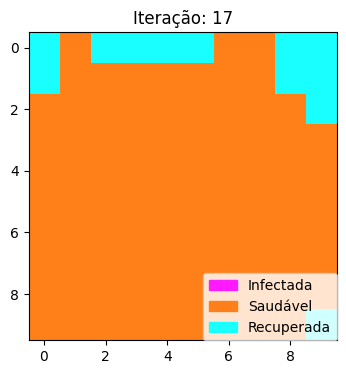

==== Iteração: 18 ====


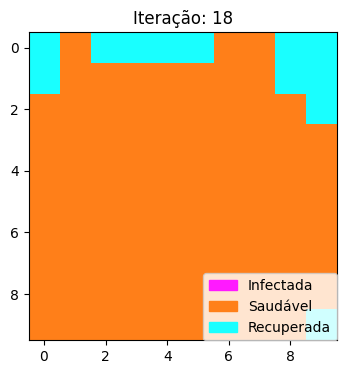

==== Iteração: 19 ====


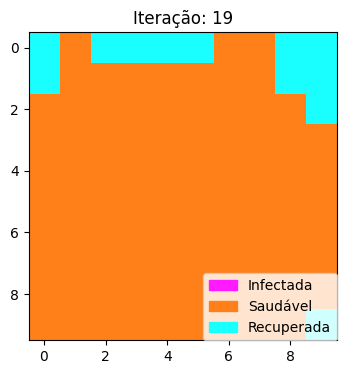

In [ ]:
rede = criarRedeSIR(
  tamanho = 100,
  quantidadePessoasInfectadas = 5
)

rede = simularSIR(
    rede = rede,
    quantidadeIteracoes = 20,
    probabilidadeInfeccao = 0.3,
    probabilidadeRecuperacao = 0.7,
    devePrintar = True,
    devePlotar = True
)

* Com a taxa de recuperação alta a doença é erradicada nas iterações iniciais, sem dar muita chance de ser propagada a outros indivíduos. Isso, evidencia que para uma doênça poder se propagar com sucesso é importante ter uma taxa de infecção alta.

### Infecção e recuperação altas
---

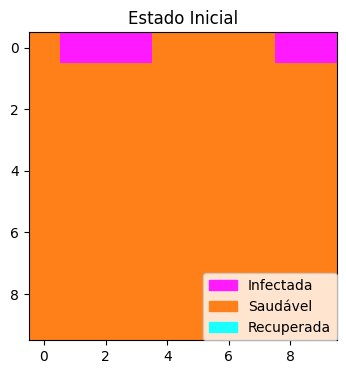

==== Iteração: 0 ====
Recuperado: (0, 1)
Recuperado: (0, 2)
Infectado: (0, 4)
Infectado: (9, 3)
Infectado: (1, 3)
Recuperado: (0, 4)
Recuperado: (0, 8)
Recuperado: (0, 9)
Recuperado: (1, 3)
Recuperado: (9, 3)


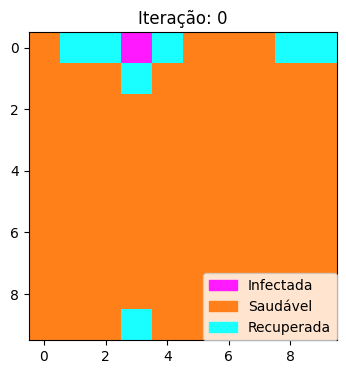

==== Iteração: 1 ====
Recuperado: (0, 3)


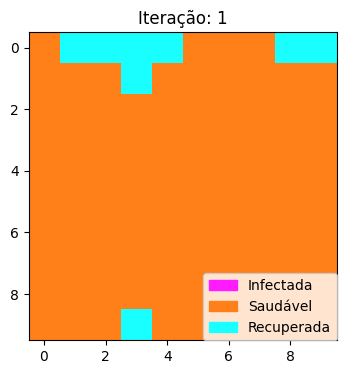

==== Iteração: 2 ====


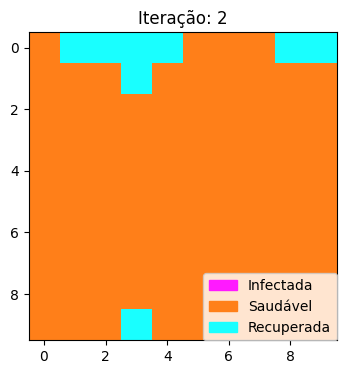

==== Iteração: 3 ====


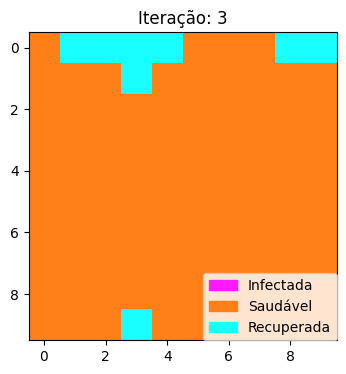

==== Iteração: 4 ====


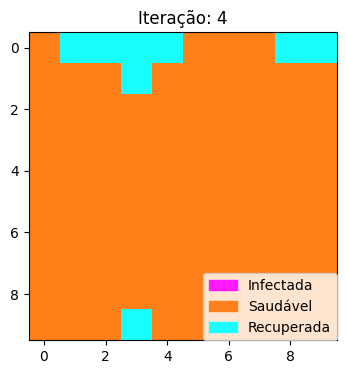

==== Iteração: 5 ====


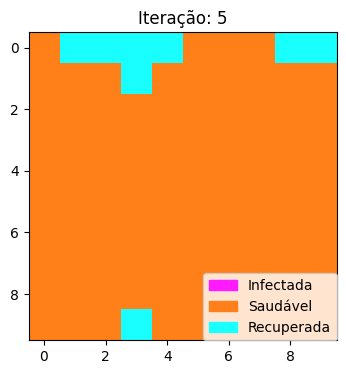

==== Iteração: 6 ====


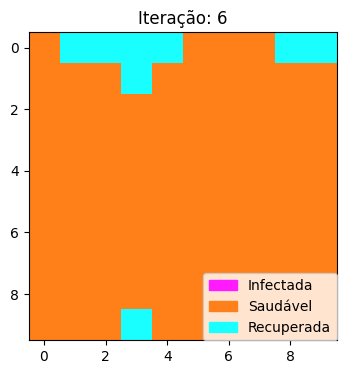

==== Iteração: 7 ====


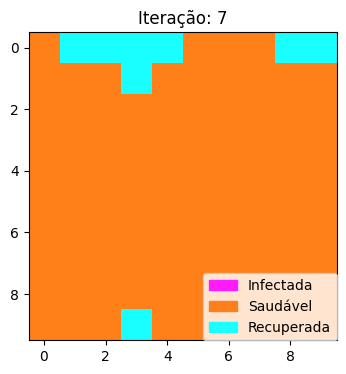

==== Iteração: 8 ====


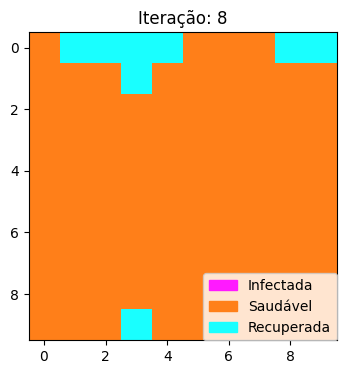

==== Iteração: 9 ====


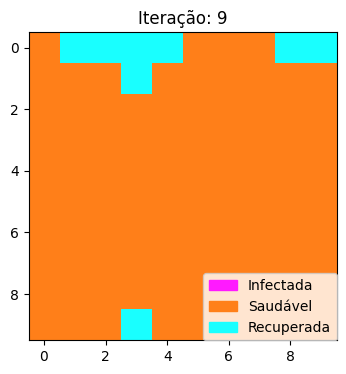

==== Iteração: 10 ====


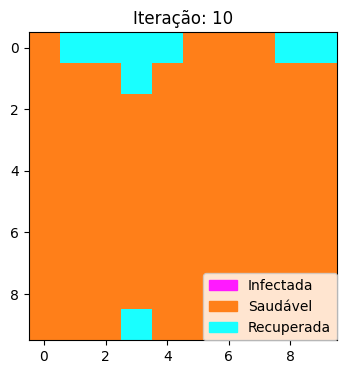

==== Iteração: 11 ====


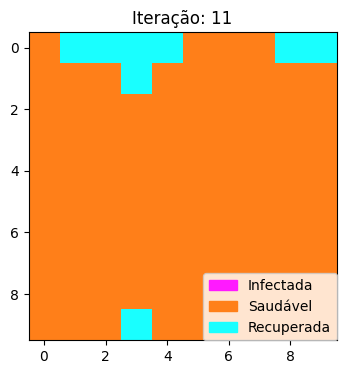

==== Iteração: 12 ====


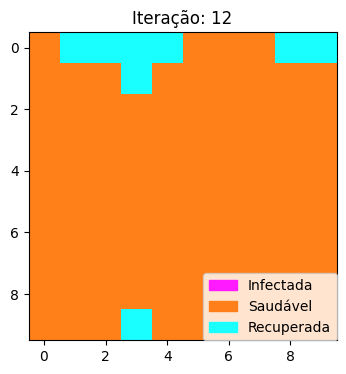

==== Iteração: 13 ====


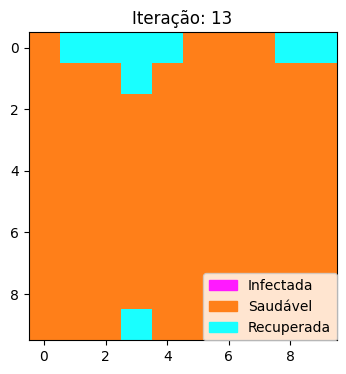

==== Iteração: 14 ====


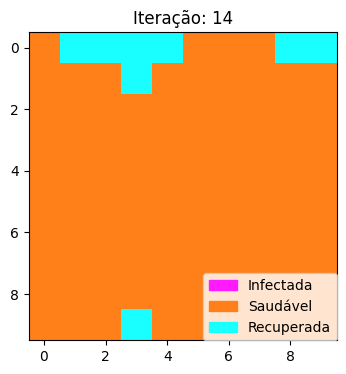

==== Iteração: 15 ====


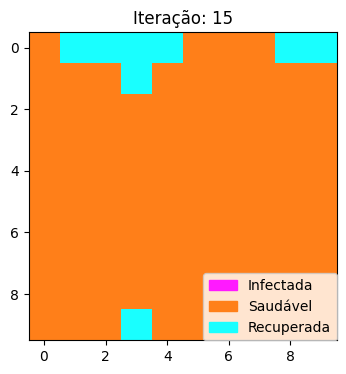

==== Iteração: 16 ====


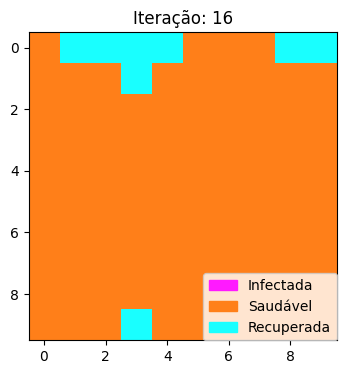

==== Iteração: 17 ====


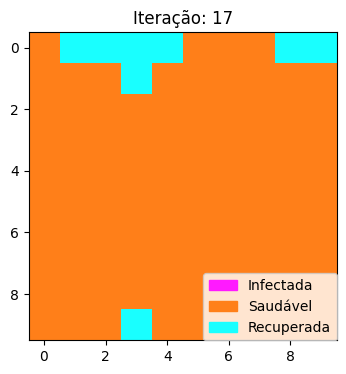

==== Iteração: 18 ====


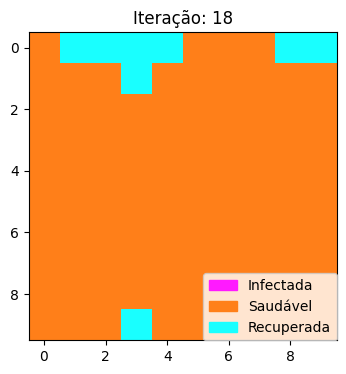

==== Iteração: 19 ====


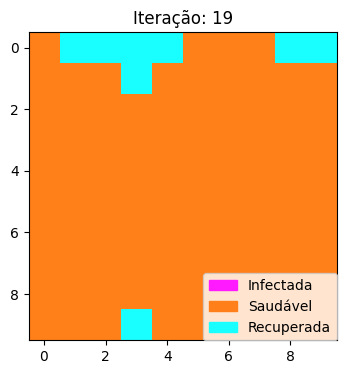

In [ ]:
rede = criarRedeSIR(
  tamanho = 100,
  quantidadePessoasInfectadas = 5
)

rede = simularSIR(
    rede = rede,
    quantidadeIteracoes = 20,
    probabilidadeInfeccao = 0.8,
    probabilidadeRecuperacao = 0.7,
    devePrintar = True,
    devePlotar = True
)

* Novamente, temos um resultado semelhante a taxa de recuperação alta e infecção baixa. Neste caso, a doença mal conseguiu se propagar entre os indivíduos e ela foi erradicada. Assim, em complemento a conclusão anterior, uma doença também precisa de uma taxa de recuperação baixa para poder atingir o máximo de pessoas possível.

##  Gráficos com as populações médias de indivíduos
---

In [ ]:
def contarIndividuosTipo(rede, tipo: int) -> int:
  contagemIndividuos: int = 0
  for i in range(len(rede)):
    for j in range(len(rede[i])):
      if(rede[i][j] == tipo):
        contagemIndividuos += 1

  return contagemIndividuos

In [ ]:
def calcularProporcaoIndividuo(rede, tipo: int) -> float:
  contagemIndividuos: int = contarIndividuosTipo(rede, tipo)
  tamanhoRede: int = (len(rede) * len(rede[0]))

  return contagemIndividuos / tamanhoRede

In [ ]:
rede = criarRedeSIR(
  tamanho = 100,
  quantidadePessoasInfectadas = 1
)

rede = simularSIR(
    rede = rede,
    quantidadeIteracoes = 20,
    probabilidadeInfeccao = 0.2,
    probabilidadeRecuperacao = 0.1,
)

proporcaoPessoasInfectadas = calcularProporcaoIndividuo(rede, PESSOA_INFECTADA)
proporcaoPessoasSaudaveis = calcularProporcaoIndividuo(rede, PESSOA_SAUDAVEL)
proporcaoPessoasRecuperadas = calcularProporcaoIndividuo(rede, PESSOA_RECUPERADA)

print(f"Proporção de pessoas infectadas: {proporcaoPessoasInfectadas}")
print(f"Proporção de pessoas saudáveis: {proporcaoPessoasSaudaveis}")
print(f"Proporção de pessoas recuperadas: {proporcaoPessoasRecuperadas}")

Proporção de pessoas infectadas: 0.0
Proporção de pessoas saudáveis: 0.99
Proporção de pessoas recuperadas: 0.01


In [ ]:
def calcularMediaIndividuosComVariasSimulacoes(
    quantidadeSimulacoes: int,
    tamanhoRede: int,
    quantidadeInicialInfectados: int,
    quantidadeIteracoes: int,
    probabilidadeInfeccao: float,
    probabilidadeRecuperacao: float
  ):

  contagemInfectados: list[int] = []
  contagemSaudaveis: list[int] = []
  contagemRecuperados: list[int] = []

  for i in range(quantidadeSimulacoes):
    rede = criarRedeSIR(
      tamanho = tamanhoRede,
      quantidadePessoasInfectadas = quantidadeInicialInfectados
    )

    rede = simularSIR(
      rede = rede,
      quantidadeIteracoes = quantidadeIteracoes,
      probabilidadeInfeccao = probabilidadeInfeccao,
      probabilidadeRecuperacao = probabilidadeRecuperacao
    )

    contagemInfectados.append(contarIndividuosTipo(rede, PESSOA_INFECTADA))
    contagemSaudaveis.append(contarIndividuosTipo(rede, PESSOA_SAUDAVEL))
    contagemRecuperados.append(contarIndividuosTipo(rede, PESSOA_RECUPERADA))

  resultados = {
      "contagemInfectados": contagemInfectados,
      "contagemSaudaveis": contagemSaudaveis,
      "contagemRecuperados": contagemRecuperados,
      "mediaInfectados": np.mean(contagemInfectados),
      "mediaSaudaveis": np.mean(contagemSaudaveis),
      "mediaRecuperados": np.mean(contagemRecuperados)
  }

  return resultados

## Variação probabilidade Infecção
---

In [ ]:
def plotGraficoMediaVariacaoInfeccao(
    quantidadeSimulacoes: int,
    tamanhoRede: int,
    quantidadeInicialInfectados: int,
    quantidadeIteracoes: int,
    probabilidadeRecuperacao: float
  ):

  probabilidadesInfeccao: list[float] = np.arange(0.1, 1.0, 0.1)

  mediaInfectados: list[float] = []
  mediaSaudaveis: list[float] = []
  mediaRecuperados: list[float] = []

  for probabilidade in probabilidadesInfeccao:
    resultados = calcularMediaIndividuosComVariasSimulacoes(
      quantidadeSimulacoes = quantidadeSimulacoes,
      tamanhoRede = tamanhoRede,
      quantidadeInicialInfectados = quantidadeInicialInfectados,
      quantidadeIteracoes = quantidadeIteracoes,
      probabilidadeInfeccao = probabilidade,
      probabilidadeRecuperacao = probabilidadeRecuperacao
    )

    mediaInfectados.append(resultados["mediaInfectados"])
    mediaSaudaveis.append(resultados["mediaSaudaveis"])
    mediaRecuperados.append(resultados["mediaRecuperados"])

  plt.figure(figsize=(8,4))
  plt.plot(probabilidadesInfeccao, mediaInfectados, label="Infectados")
  plt.plot(probabilidadesInfeccao, mediaSaudaveis, label="Saudaveis")
  plt.plot(probabilidadesInfeccao, mediaRecuperados, label="Recuperados")
  plt.title("Média de Individuos - Variação Probabilidade Infecção")
  plt.xlabel("Probabilidade de Infecção")
  plt.ylabel("Média de Individuos")
  plt.legend()
  plt.show()


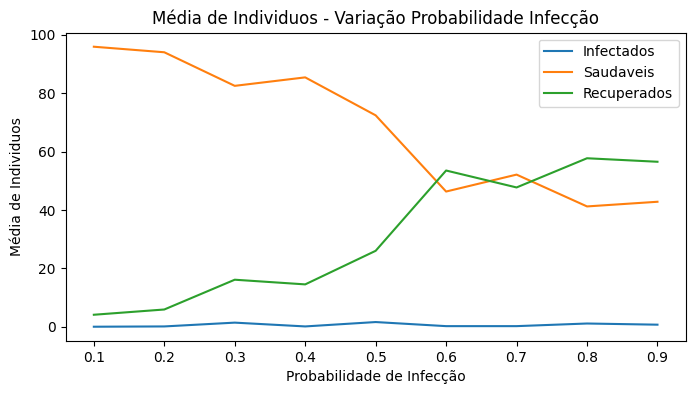

In [ ]:
plotGraficoMediaVariacaoInfeccao(
  quantidadeSimulacoes = 10,
  tamanhoRede = 100,
  quantidadeInicialInfectados = 1,
  quantidadeIteracoes = 20,
  probabilidadeRecuperacao = 0.3
)

## Variação probabilidade Recuperação
---

In [ ]:
def plotGraficoMediaVariacaoRecuperacao(
    quantidadeSimulacoes: int,
    tamanhoRede: int,
    quantidadeInicialInfectados: int,
    quantidadeIteracoes: int,
    probabilidadeInfeccao: float
  ):

  probabilidadesRecuperacao: list[float] = np.arange(0.1, 1.0, 0.1)

  mediaInfectados: list[float] = []
  mediaSaudaveis: list[float] = []
  mediaRecuperados: list[float] = []

  for probabilidade in probabilidadesRecuperacao:
    resultados = calcularMediaIndividuosComVariasSimulacoes(
      quantidadeSimulacoes = quantidadeSimulacoes,
      tamanhoRede = tamanhoRede,
      quantidadeInicialInfectados = quantidadeInicialInfectados,
      quantidadeIteracoes = quantidadeIteracoes,
      probabilidadeInfeccao = probabilidadeInfeccao,
      probabilidadeRecuperacao = probabilidade
    )

    mediaInfectados.append(resultados["mediaInfectados"])
    mediaSaudaveis.append(resultados["mediaSaudaveis"])
    mediaRecuperados.append(resultados["mediaRecuperados"])

  plt.figure(figsize=(8,4))
  plt.plot(probabilidadesRecuperacao, mediaInfectados, label="Infectados")
  plt.plot(probabilidadesRecuperacao, mediaSaudaveis, label="Saudaveis")
  plt.plot(probabilidadesRecuperacao, mediaRecuperados, label="Recuperados")
  plt.title("Média de Individuos - Variação Probabilidade Recuperação")
  plt.xlabel("Probabilidade de Recuperacao")
  plt.ylabel("Média de Individuos")
  plt.legend()
  plt.show()


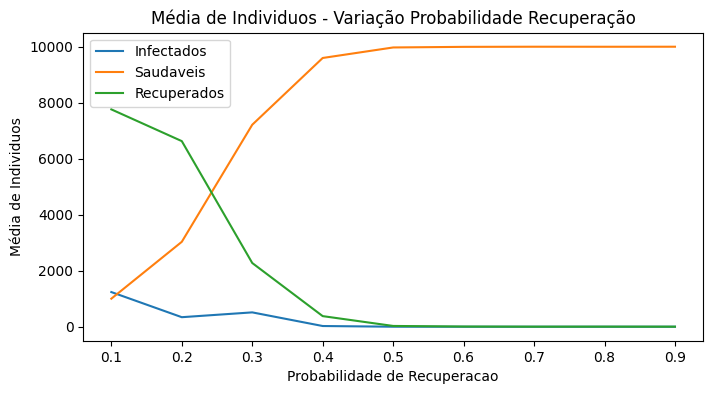

In [ ]:
plotGraficoMediaVariacaoRecuperacao(
  quantidadeSimulacoes = 10,
  tamanhoRede = 10000,
  quantidadeInicialInfectados = 1,
  quantidadeIteracoes = 20,
  probabilidadeInfeccao = 0.8,
)

* É possível notar, a partir dos gráficos, que com probabilidades de recuperção altas a tendência é que a doênça seja erradicada bem cedo e mantenha muitas pessoas saúdáveis, em média. Além disso, por consequência, a quantidade de recuperados, também, tende a reduzir, uma vez que a quantidade de infectados se torna consideravelmente menor.